<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula26c%20-%20Single%20Hidden%20Layer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

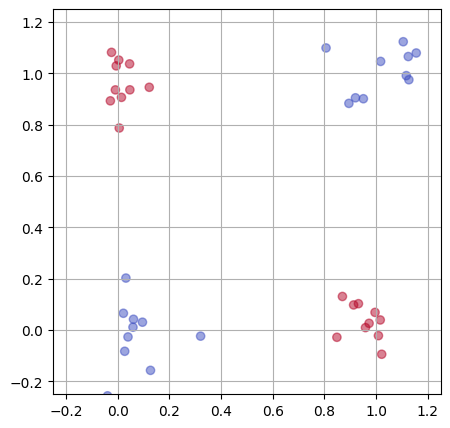

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

n_samples = 40

def generateLogicalDataset(n_samples,
                           func=lambda a, b: bool(a) != bool(b)):
    X, y = make_blobs(n_samples=n_samples,
                      centers=[[0,0],[1,0],[1,1],[0,1]],
                      cluster_std=0.1)
    y = np.array([func(a>0.5, b>0.5) for a, b in zip(X[:,0], X[:,1])], dtype=int) * 2 -1
    return X, y

def plotDataset(X, y, xlim=(-0.25, 1.25), ylim=(-0.25, 1.25)):
    plt.figure(figsize=(5, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y, marker='o', alpha=0.5, cmap="coolwarm")
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.grid(True)

X, y = generateLogicalDataset(n_samples)
plotDataset(X, y)
plt.show()

In [2]:
def defineAxes(X):
  offset = 0.5
  min0, max0 = X[:, 0].min(), X[:, 0].max()
  min1, max1 = X[:, 1].min(), X[:, 1].max()
  return [min0-offset, max0+offset], [min1-offset, max1+offset]

def plotPredictions(model, X):
  axis0, axis1 = defineAxes(X)
  x0s = np.linspace(axis0[0], axis0[1], 100)
  x1s = np.linspace(axis1[0], axis1[1], 100)
  x0, x1 = np.meshgrid(x0s, x1s)
  X = np.c_[x0.ravel(), x1.ravel()]
  ypred = model.predict(X).reshape(x0.shape)
  plt.contourf(x0, x1, ypred, cmap='coolwarm', alpha=0.2)

Accuracy: 1.0


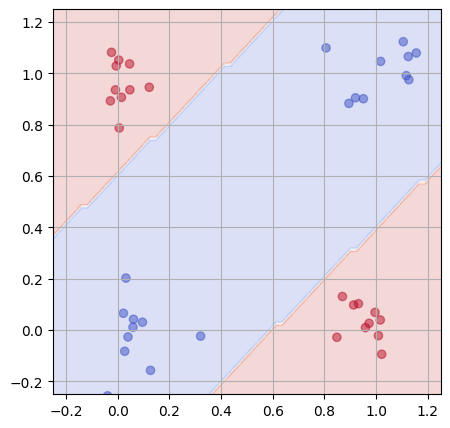

In [52]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

class LastLayer_v2(BaseEstimator, ClassifierMixin):
    def __init__(self, max_iter=1000, learning_rate=0.01):
        self.max_iter = max_iter
        self.learning_rate = learning_rate

    def fit(self, X, y):
        y = y.reshape(-1, 1)
        self.ihw = np.array([[0.5, -1, 1], [0.5, 1 ,-1]]).T
        Xb = include_bias(X)
        self.pH = Xb @ self.ihw
        self.H = np.tanh(self.pH)
        Hb = include_bias(self.H)
        self.how = np.random.randn(Hb.shape[1], 1)
        for _ in range(self.max_iter):
            logits = Hb @ self.how
            error = y - logits
            self.how += self.learning_rate * Hb.T @ error
        return self

    def predict(self, X):
        Xb = include_bias(X)
        self.pH = Xb @ self.ihw
        self.H = np.tanh(self.pH)
        Hb = include_bias(self.H)
        logits = Hb @ self.how
        return np.sign(logits)

model = LastLayer_v2()
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
plotDataset(X, y)
plotPredictions(model, X)
plt.show()

Accuracy: 1.0


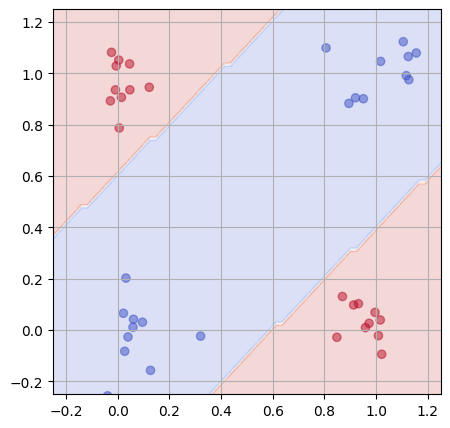

In [57]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

class LastLayer_v3(BaseEstimator, ClassifierMixin):
    def __init__(self, max_iter=1000, learning_rate=0.01):
        self.max_iter = max_iter
        self.learning_rate = learning_rate

    def fit(self, X, y):
        y = y.reshape(-1, 1)
        self.ihw = np.array([[0.5, -1, 1], [0.5, 1 ,-1]]).T
        self.how = np.random.randn(self.ihw.shape[1]+1, 1)
        for _ in range(self.max_iter):
            logits = self.forward(X)
            error = y - logits
            self.how += self.learning_rate * self.Hb.T @ error
        return self

    def forward(self, X):
        Xb = include_bias(X)
        self.pH = Xb @ self.ihw
        self.H = np.tanh(self.pH)
        self.Hb = include_bias(self.H)
        logits = self.Hb @ self.how
        return logits

    def predict(self, X):
        logits = self.forward(X)
        return np.sign(logits)

model = LastLayer_v3()
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
plotDataset(X, y)
plotPredictions(model, X)
plt.show()

Accuracy: 1.0


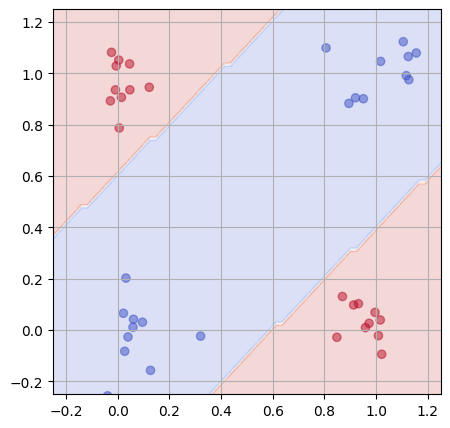

In [58]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

class LastLayer_v4(BaseEstimator, ClassifierMixin):
    def __init__(self, max_iter=1000, learning_rate=0.01):
        self.max_iter = max_iter
        self.learning_rate = learning_rate

    def fit(self, X, y):
        y = y.reshape(-1, 1)
        self.ihw = np.array([[0.5, -1, 1], [0.5, 1 ,-1]]).T
        self.how = np.random.randn(self.ihw.shape[1]+1, 1)
        for _ in range(self.max_iter):
            logits = self.forward(X)
            self.backward(y, logits)
        return self

    def backward(self, y, logits):
        error = y - logits
        self.how += self.learning_rate * self.Hb.T @ error

    def forward(self, X):
        Xb = include_bias(X)
        self.pH = Xb @ self.ihw
        self.H = np.tanh(self.pH)
        self.Hb = include_bias(self.H)
        logits = self.Hb @ self.how
        return logits

    def predict(self, X):
        logits = self.forward(X)
        return np.sign(logits)

model = LastLayer_v4()
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
plotDataset(X, y)
plotPredictions(model, X)
plt.show()

Accuracy: 1.0


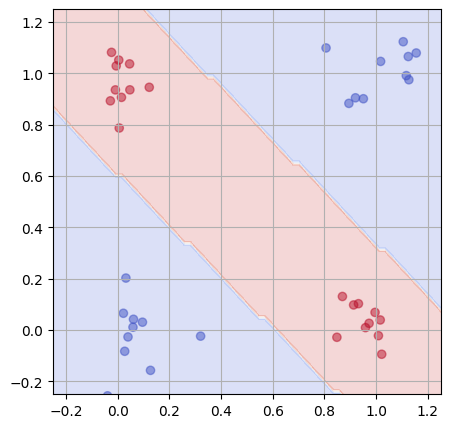

In [67]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

class SingleHiddenLayer(BaseEstimator, ClassifierMixin):
    def __init__(self, max_iter=10000, learning_rate=0.01):
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.n_hidden = 2

    def fit(self, X, y):
        y = y.reshape(-1, 1)
        self.ihw = np.random.randn(X.shape[1]+1, self.n_hidden)
        self.how = np.random.randn(self.ihw.shape[1]+1, 1)
        for _ in range(self.max_iter):
            logits = self.forward(X)
            self.backward(y, logits)
        return self

    def backward(self, y, logits):
        ho_delta = y - logits
        ho_grad = self.Hb.T @ ho_delta
        ### ### ### ###
        tanh_grad = (1 - self.H**2)
        ih_delta = ho_delta @ self.how[1:].T * tanh_grad
        ### ### ### ###
        ih_grad = self.Xb.T @ ih_delta
        self.ihw += self.learning_rate * ih_grad
        self.how += self.learning_rate * ho_grad

    def forward(self, X):
        self.Xb = include_bias(X)
        self.pH = self.Xb @ self.ihw
        self.H = np.tanh(self.pH)
        self.Hb = include_bias(self.H)
        logits = self.Hb @ self.how
        return logits

    def predict(self, X):
        logits = self.forward(X)
        return np.sign(logits)

model = SingleHiddenLayer()
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
plotDataset(X, y)
plotPredictions(model, X)
plt.show()